# Connectivity motifs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib

from brokenaxes import brokenaxes

In [4]:
##  PLOS

plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 12,                  # Base size 8-12 pt

    # Axes
    "axes.titlesize": 12,             # Axis title size
    "axes.labelsize": 12,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles

    # Ticks
    "xtick.labelsize": 9,             # X tick label size (8-12)
    "ytick.labelsize": 9,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction

    # Legends
    "legend.fontsize": 12,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location

    # Resolution
    "figure.dpi": 500,                # Display DPI
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace

    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif

    # Figsize ?
    "figure.figsize": (16, 6)       # Figsize
    # "figure.figsize": (8, 6)       # Figsize
})

In [3]:
plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 14,                  # Base size 8-12 pt
    # Axes
    "axes.titlesize": 18,             # Axis title size
    "axes.labelsize": 18,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles
    # Ticks
    "xtick.labelsize": 16,             # X tick label size (8-12)
    "ytick.labelsize": 16,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction
    # Legends
    "legend.fontsize": 18,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location
    # Resolution
    # "figure.dpi": 500,                # Display DPI  UNCOMMENT LATER. I commented it out now while I work on it, because Jupyter displayed pixel size = figsize * figure.dpi, causing huge images now in the notebook
    "figure.dpi": 100,
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace
    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif
})

In [5]:
## Reusable color utility
# I use this one
import numpy as np
import matplotlib.pyplot as plt

def make_color_map(values, cmap, vmin=0.25, vmax=1.0):
    '''
    Function that takes array of values and make a colormap for them
    '''
    values_sorted = sorted(values)
    colors = cmap(np.linspace(vmin, vmax, len(values)))
    return dict(zip(values_sorted, colors))

# To be given value
v_rest = [-22, -17, -12.3, -8.5]
pqif_vector = [0, 0.25, 0.5, 0.75, 1]

# Make colors once
color_map_vrest = make_color_map(v_rest, plt.cm.Reds)  # Reds for vrest
color_map_pqif = make_color_map(pqif_vector[1:-1], plt.cm.Greens)  # Greens for pqif

# Explicit endpoints for pqif
color_map_pqif[pqif_vector[0]] = 'black'
color_map_pqif[pqif_vector[-1]] = 'steelblue'


# Path

In [26]:
import os

figure_folder = 'figures'

# Dataframe

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

dynamics = ["oscillations", "sequences"]
# simulations_osc = [1, 2, 3, 4]
# simulations_seq = [9, 10, 11, 12]
# v_rest = [-22, -17, -12.3, -8.5]
slope_qif = 10.74

pqif_values = [0, 0.25, 0.5, 0.75, 1]
lif_mix = [0, 0.25, 0.5, 0.75]
qif = [1]
names = ['LIF', '0.25', '0.5', '0.75', 'QIF']
# # Parámetros estéticos y valores de pqif
# colors = ['firebrick', 'firebrick', 'steelblue']

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]
motif_labels = {
    "tau_rec": "Reciprocal",
    "tau_div": "Divergent",
    "tau_con": "Convergent",
    "tau_chn": "Chain"
}

dfs = []

for dyn in dynamics:

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
    else:
        print('Invalid dynamics')
        sys.exit()

    # Crear figura
    # fig, axs = plt.subplots(1, 4, figsize=(16, 6), sharey=True)



    for sim, vr, f in zip(simulation_number, vrest, slope):


        # Cargar datos
        dataframe_title = f'{dyn}/simulation_{sim}/simulation_{sim}_results.csv'
        # dataframe_title = ONEDRIVE_BASE / f"simulation_{sim}_results.csv"
        df_results = pd.read_csv(dataframe_title)  # Has header

        print(f"{dyn}, sim {sim}:")
        # display(df_results)


        sorted = df_results.sort_values(by=['pqif', 'seed'])

        # if sim == simulation_number[0]:
        #     display(sorted)

        # for pqif, name in zip(pqif_values, names):
        for pqif in pqif_values:

            # df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['nloop'] == 15) & (df_results['seed']==0)]


            df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['nloop'] == 15)]
            
            # df_filtered2 = sorted[(sorted['pqif'] == pqif) & (sorted['nloop'] == 15)]

            # display(df_filtered2)
            display(df_filtered.head(3))

            # dfs.append(df_filtered)


            # display(df_filtered)

# display(test_1)
# display(test_2)

# df_motifs = pd.concat(dfs, ignore_index=True)
# display(df_motifs)

oscillations, sim 1:


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn
1615,0.0,0,15,13.050491,-0.007263,0.000309,-0.004935,0.000362
1631,0.0,1,15,10.858565,0.001052,-0.000127,-0.004942,-0.000161
1647,0.0,2,15,10.938580,-0.000472,-0.000404,-0.004941,0.000007


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn
3215,0.25,0,15,12.722973,-0.027613,0.000057,-0.004826,0.000167
3231,0.25,1,15,11.611555,-0.032991,-0.000197,-0.004796,-0.000009
3247,0.25,2,15,11.662436,-0.027823,0.000287,-0.004841,0.000466


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn
15,0.5,0,15,12.293012,-0.052239,0.000390,-0.004691,0.000216
31,0.5,1,15,13.242411,-0.034508,0.000026,-0.004667,0.000272
47,0.5,2,15,12.549276,-0.039697,0.000673,-0.004676,0.000485


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn
2415,0.75,0,15,14.951404,-0.054854,0.000108,-0.004555,0.000431
2431,0.75,1,15,14.001210,-0.052870,-0.000193,-0.004747,0.000526
2447,0.75,2,15,14.842502,-0.053233,-0.000280,-0.004595,0.000353


...

,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn
815,0.0,0,15,11.822102,0.088335,0.005633,-0.004828,-0.001510
831,0.0,1,15,11.724388,0.076958,0.008708,-0.004818,-0.001428
847,0.0,2,15,12.669499,0.070743,0.004653,-0.004848,-0.001468


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn
15,0.25,0,15,9.529196,0.099114,0.008321,-0.004796,-0.001691
31,0.25,1,15,11.011925,0.072993,0.012487,-0.004837,-0.001205
47,0.25,2,15,10.803643,0.070259,0.010054,-0.004826,-0.001093


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn
1615,0.5,0,15,8.932138,0.098190,0.011267,-0.004782,-0.002053
1631,0.5,1,15,8.140902,0.120351,0.005823,-0.004764,-0.001948
1647,0.5,2,15,8.749924,0.106064,0.010332,-0.004777,-0.001672


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn
2415,0.75,0,15,9.409218,0.099282,0.016239,-0.004775,-0.002583
2431,0.75,1,15,9.152883,0.088614,0.015196,-0.004781,-0.002004
2447,0.75,2,15,8.831929,0.105235,0.017371,-0.004765,-0.002311


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn
3215,1.0,0,15,8.856897,0.100118,0.023605,-0.004757,-0.003201
3231,1.0,1,15,8.796776,0.085817,0.020455,-0.004760,-0.003040
3247,1.0,2,15,7.201968,0.134577,0.010679,-0.004722,-0.002755


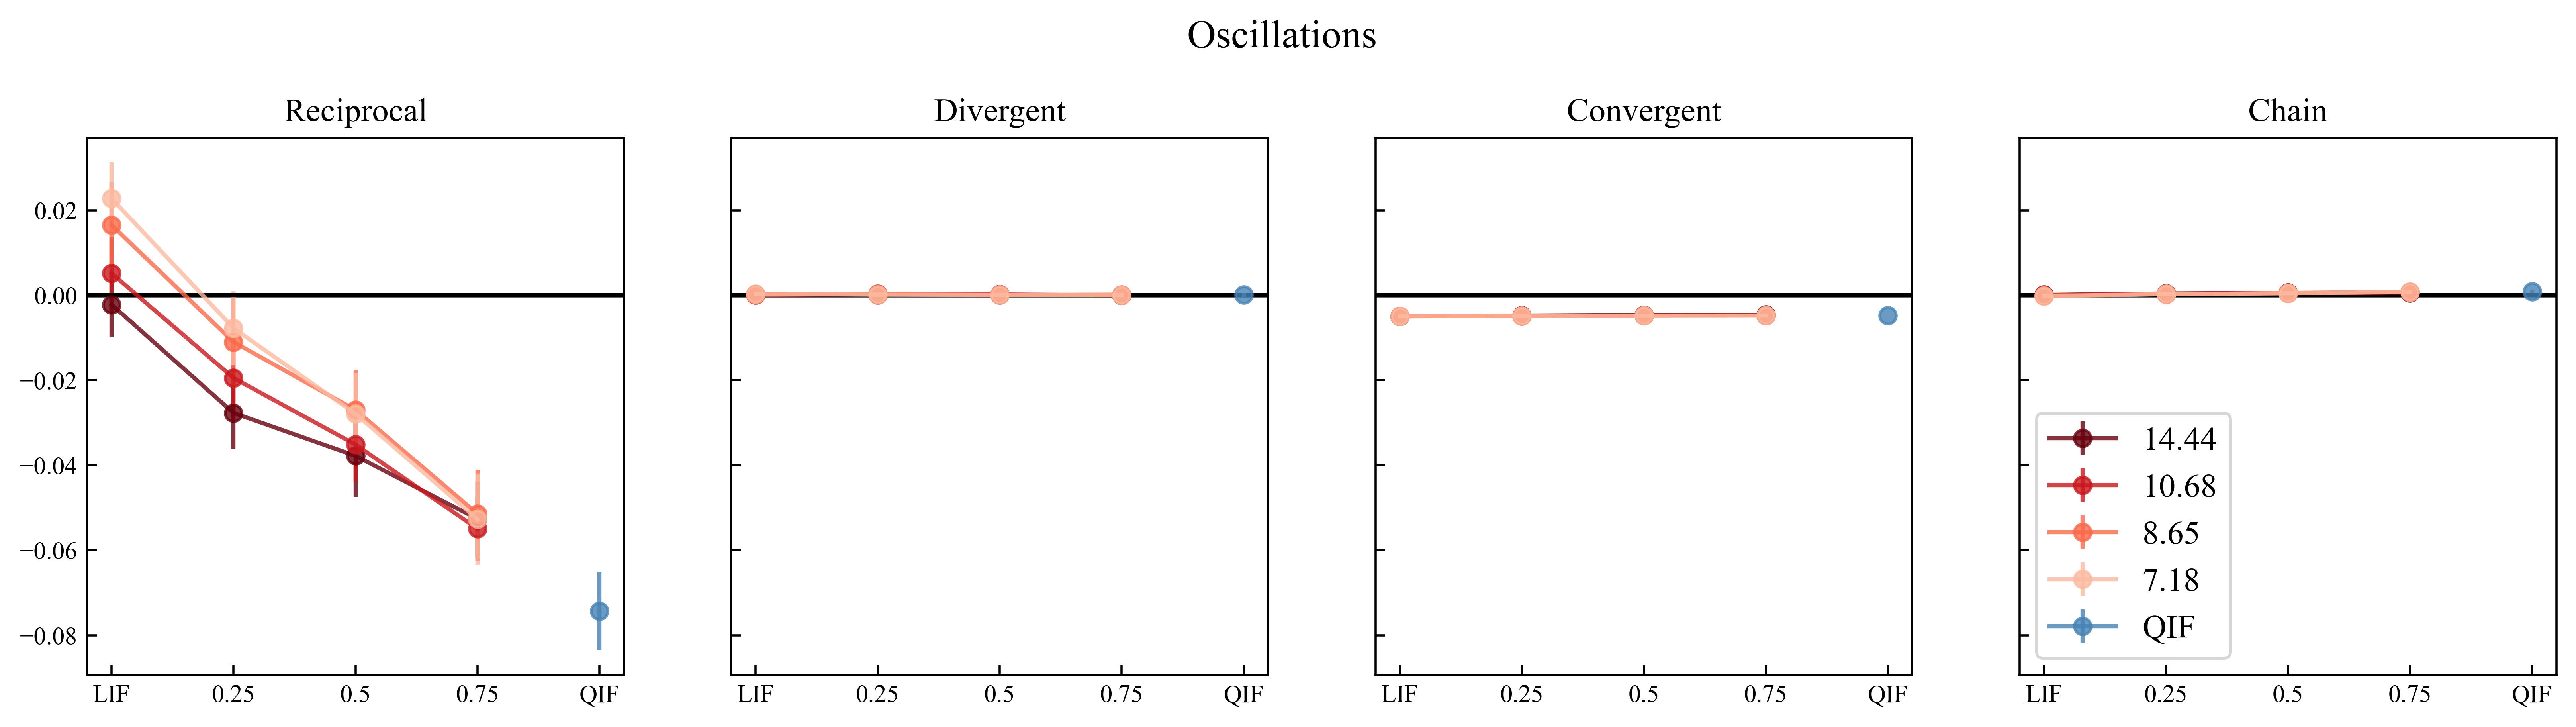

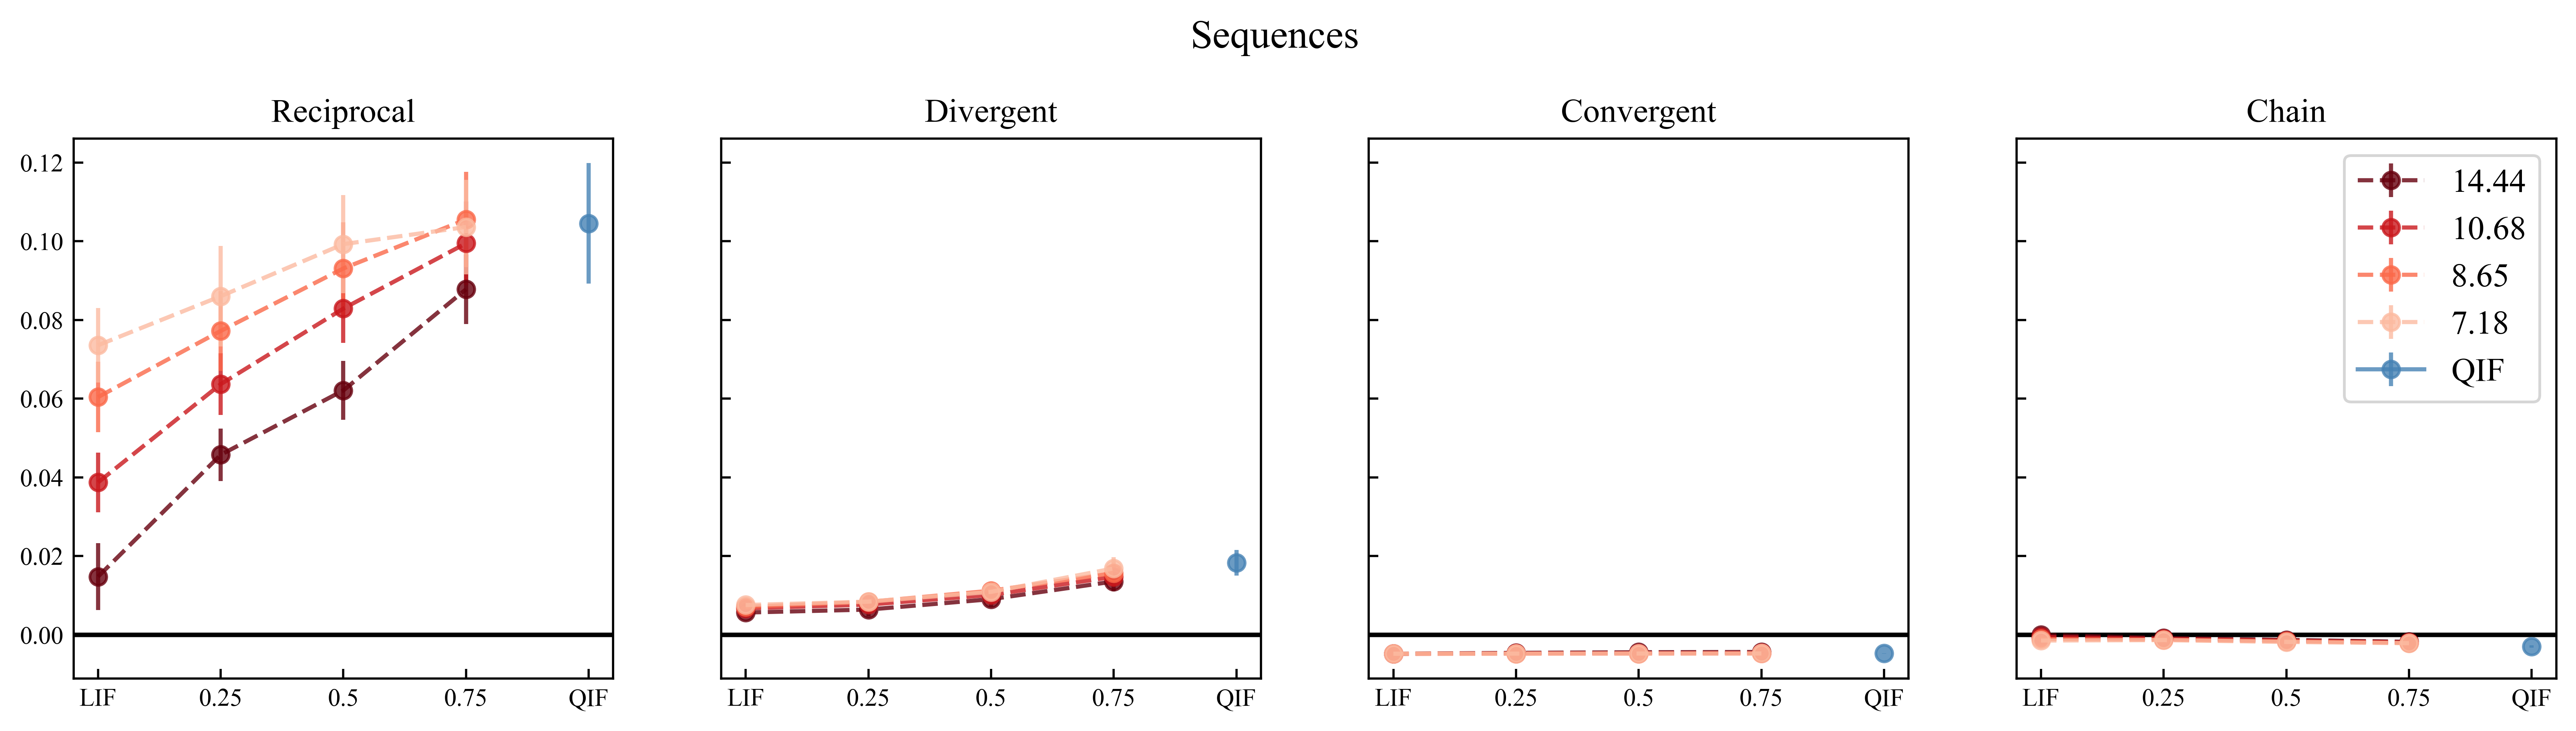

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dynamics = ["oscillations", "sequences"]
# simulations_osc = [1, 2, 3, 4]
# simulations_seq = [9, 10, 11, 12]
# v_rest = [-22, -17, -12.3, -8.5]
slope_qif = 10.74

pqif_values = [0, 0.25, 0.5, 0.75, 1]
lif_mix = [0, 0.25, 0.5, 0.75]
qif = [1]
names = ['LIF', '0.25', '0.5', '0.75', 'QIF']
# # Parámetros estéticos y valores de pqif
# colors = ['firebrick', 'firebrick', 'steelblue']

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]
motif_labels = {
    "tau_rec": "Reciprocal",
    "tau_div": "Divergent",
    "tau_con": "Convergent",
    "tau_chn": "Chain"
}

for dyn in dynamics:

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
        linestyle = '-'
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
        linestyle = '--'
    else:
        print('Invalid dynamics')
        sys.exit()

    # Crear figura
    fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    figname = f"{dyn}_heterogenous_motifs.svg"



    for sim, vr, f in zip(simulation_number, vrest, slope):


        # Cargar datos
        dataframe_title = f'{dyn}/simulation_{sim}/simulation_{sim}_results.csv'
        # dataframe_title = ONEDRIVE_BASE / f"simulation_{sim}_results.csv"
        df_results = pd.read_csv(dataframe_title)

        xs = []
        ys = {motif: [] for motif in motifs}
        yerrs = {motif: [] for motif in motifs}

        # display(df_results)


        # for pqif, name in zip(pqif_values, names):
        for pqif in lif_mix:


            if pqif != 1:
                color = color_map_vrest[vr]
            else:
                color = 'steelblue'

            df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['nloop'] == 15)]  # is now a dataframe for current condition, with 50 seeds

            stats = df_filtered[motifs].agg(["mean", "std"])  # Applies aggregate parameters on columns (motifs) across seeds
            # display(stats)

            xs.append(pqif)

            for i, motif in enumerate(motifs):
                ax = axs[i]  # One ax object per motif
                # e.g. axs[0] -> reciprocal, etc..

                ys[motif].append(stats.loc["mean", motif])
                yerrs[motif].append(stats.loc["std", motif])

        for i, motif in enumerate(motifs):
            axs[i].errorbar(
                xs,
                ys[motif],
                yerr=yerrs[motif],
                marker='o',
                label=f,
                alpha=0.8,
                linestyle=linestyle,
                color=color_map_vrest[vr]
            )

            axs[i].axhline(0, color='black')
            axs[i].set_xticks(pqif_values, names)
            axs[i].set_title(motif_labels[motif])
            axs[i].set_box_aspect(1)
            # axs[i].set_ylim()
            
    # TODO collapse all QIF and plot alone

    # QIF separate
    # TODO decide on a specific simulation?
    df_qif = df_results[(df_results['pqif'] == 1) & (df_results['nloop'] == 15)]  # is now a dataframe for QIF, with 50 seeds TODO

    stats_qif = df_qif[motifs].agg(["mean", "std"])  # Applies aggregate parameters on columns (motifs) across seeds

    # x_qif = [1]  # QIF
    ys_qif = {motif: [] for motif in motifs}
    yerrs_qif = {motif: [] for motif in motifs}


    for i, motif in enumerate(motifs):
        ys_qif[motif].append(stats_qif.loc["mean", motif])
        yerrs_qif[motif].append(stats_qif.loc["std", motif])
        
        axs[i].errorbar(
            1,
            ys_qif[motif],
            yerr=yerrs_qif[motif],
            marker='o',
            label="QIF",
            alpha=0.8,
            color='steelblue'
        )

    
    plt.legend()
    plt.suptitle(f"{dyn.capitalize()}")
    full_path = os.path.join(figure_folder, figname)
    plt.savefig(full_path, format="svg")
    plt.show